# HGB 03 — Training

Train the candidate classifiers using the common development folds and training-derived Peak thresholds.

In [1]:
# Import libraries
from pathlib import Path
import sys

In [2]:
# Define the root directory of the project and config file
PROJECT_ROOT = Path.cwd()
while not (PROJECT_ROOT / "src").exists() and PROJECT_ROOT != PROJECT_ROOT.parent:
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

CONFIG_PATH = PROJECT_ROOT / "configs" / "hist_gradient_boosting_classifier.yaml"
CONFIG_PATH

WindowsPath('e:/jcuenca/OneDrive - GUSCanada/5toTerm/01_Capstone/Codigo/ontario-electricity-peak-risk/configs/hist_gradient_boosting_classifier.yaml')

One classifier is fitted for every `peak_h01 ... peak_h24`. The final 2025 holdout is not evaluated.

In [3]:
# Import functions to run hist_gradient_boosting model
from src.ontario_peak_risk.models.peak_risk.hist_gradient_boosting.run_model import (
    run_hist_gradient_boosting_classifier,
)

In [21]:
# Run the model - hist_gradient_boosting
results = run_hist_gradient_boosting_classifier(CONFIG_PATH)

HistGradientBoostingClassifier completed successfully.
Best parameters: {'learning_rate': 0.08, 'max_iter': 160, 'max_leaf_nodes': 31, 'min_samples_leaf': 40, 'l2_regularization': 1.0}
Final 2025 holdout evaluated: NO


In [6]:
# Display results
results["fold_metrics"]

,fold,precision,recall,f1,balanced_accuracy,n_observations,positive_rate_pct,pr_auc,roc_auc
0,fold_2023,0.903146,0.141082,0.244042,0.569609,1257984,10.965243,0.624529,0.900519
1,fold_2024,0.756246,0.389038,0.513774,0.691900,1261440,4.009386,0.682029,0.980039


### Hyperparameter Tuning

Review moderate tuning based on PR-AUC across representative horizons and validation folds.

In [7]:
# Display tuning_summary
results["tuning_summary"]

,parameter_id,learning_rate,max_iter,max_leaf_nodes,min_samples_leaf,l2_regularization,mean_pr_auc,mean_f1,mean_recall
0,3,0.08,160,31,40,1.0,0.670951,0.410866,0.294315
1,2,0.05,200,31,30,0.5,0.664098,0.390264,0.274296
2,4,0.10,120,15,30,1.0,0.663852,0.392238,0.275928
3,1,0.05,160,15,20,0.0,0.647935,0.360453,0.246270


In [8]:
# Display best_parameters 
results["best_parameters"]

{'learning_rate': 0.08,
 'max_iter': 160,
 'max_leaf_nodes': 31,
 'min_samples_leaf': 40,
 'l2_regularization': 1.0}

### Evaluation

Review standardized Peak-Risk metrics and key diagnostic visualizations.

In [9]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import precision_recall_curve, confusion_matrix, ConfusionMatrixDisplay

In [10]:
# Display global_metrics 
results["global_metrics"]

,model,precision,recall,f1,balanced_accuracy,n_observations,positive_rate_pct,pr_auc,roc_auc
0,hist_gradient_boosting_classifier,0.822794,0.207605,0.331553,0.601994,2519424,7.482544,0.579909,0.908734


In [11]:
# Display fold_metrics 
results["fold_metrics"]

,fold,precision,recall,f1,balanced_accuracy,n_observations,positive_rate_pct,pr_auc,roc_auc
0,fold_2023,0.903146,0.141082,0.244042,0.569609,1257984,10.965243,0.624529,0.900519
1,fold_2024,0.756246,0.389038,0.513774,0.691900,1261440,4.009386,0.682029,0.980039


In [12]:
# Display fsa_metrics
results["fsa_metrics"]

,fold,fsa,precision,recall,f1,balanced_accuracy,n_observations,positive_rate_pct,pr_auc,roc_auc
0,fold_2023,L4T,0.650447,0.291918,0.402980,0.644439,209664,1.900183,0.468212,0.941267
1,fold_2023,M5R,0.804181,0.279554,0.414884,0.639094,209664,1.968864,0.596332,0.969306
2,fold_2023,M5S,0.674270,0.446256,0.537064,0.721398,209664,1.579670,0.603398,0.979845
3,fold_2023,M6G,0.943717,0.166410,0.282930,0.582912,209664,5.574634,0.644767,0.942074
4,fold_2023,M9R,0.860177,0.206721,0.333333,0.602775,209664,3.363954,0.564919,0.940455
5,fold_2023,M9W,0.990789,0.113782,0.204123,0.556332,209664,51.404151,0.896261,0.893199
6,fold_2024,L4T,0.785038,0.408673,0.537524,0.702727,210240,2.796804,0.715102,0.988084
7,fold_2024,M5R,0.687848,0.349773,0.463735,0.673532,210240,1.678082,0.596313,0.987548
8,fold_2024,M5S,0.569760,0.324580,0.413562,0.660602,210240,1.358447,0.509880,0.987707
9,fold_2024,M6G,0.737309,0.498955,0.595155,0.746118,210240,3.641553,0.699630,0.981135


In [13]:
# Display horizon_metrics
results["horizon_metrics"]

,fold,horizon,precision,recall,f1,balanced_accuracy,n_observations,positive_rate_pct,pr_auc,roc_auc
0,fold_2023,1,0.959343,0.213651,0.349473,0.606269,52416,10.956578,0.740016,0.933544
1,fold_2023,2,0.950692,0.191363,0.318597,0.595071,52416,10.956578,0.741422,0.939489
2,fold_2023,3,0.953244,0.173951,0.294213,0.586451,52416,10.956578,0.707212,0.928036
3,fold_2023,4,0.940075,0.174822,0.294817,0.586725,52416,10.956578,0.716770,0.930661
4,fold_2023,5,0.935357,0.166289,0.282377,0.582438,52416,10.956578,0.714369,0.927487
5,fold_2023,6,0.934844,0.172384,0.291091,0.585453,52416,10.956578,0.709050,0.922395
6,fold_2023,7,0.936475,0.159150,0.272064,0.578911,52416,10.956578,0.698078,0.922086
7,fold_2023,8,0.934625,0.134425,0.235043,0.566634,52416,10.956578,0.657410,0.907752
8,fold_2023,9,0.922989,0.139822,0.242855,0.569193,52416,10.956578,0.647367,0.904266
9,fold_2023,10,0.917738,0.124325,0.218985,0.561477,52416,10.956578,0.637022,0.905226


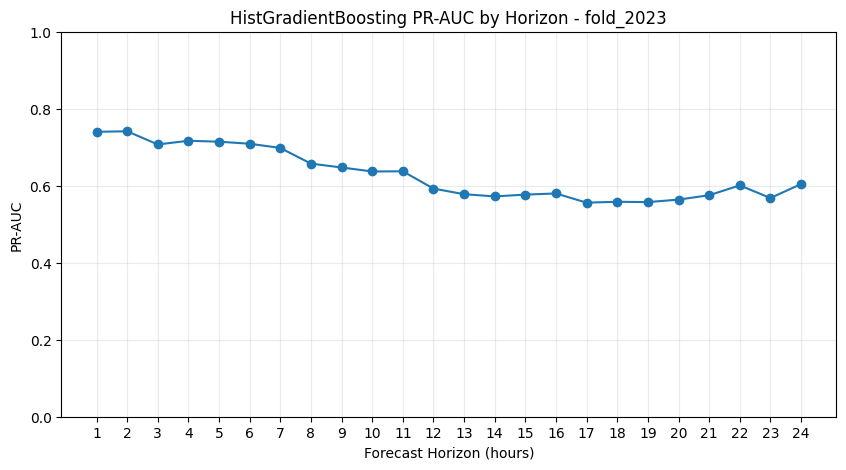

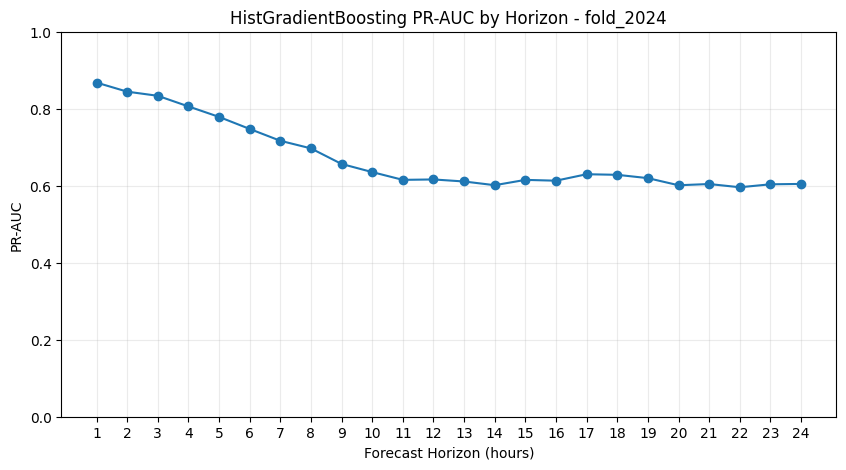

In [14]:
# PR-AUC by forecast horizon
for fold, group in results["horizon_metrics"].groupby("fold"):
    plt.figure(figsize=(10, 5))
    plt.plot(group["horizon"], group["pr_auc"], marker="o")
    plt.xlabel("Forecast Horizon (hours)")
    plt.ylabel("PR-AUC")
    plt.title(f"HistGradientBoosting PR-AUC by Horizon - {fold}")
    plt.ylim(0, 1)
    plt.xticks(range(1, 25))
    plt.grid(alpha=0.25)
    plt.show()


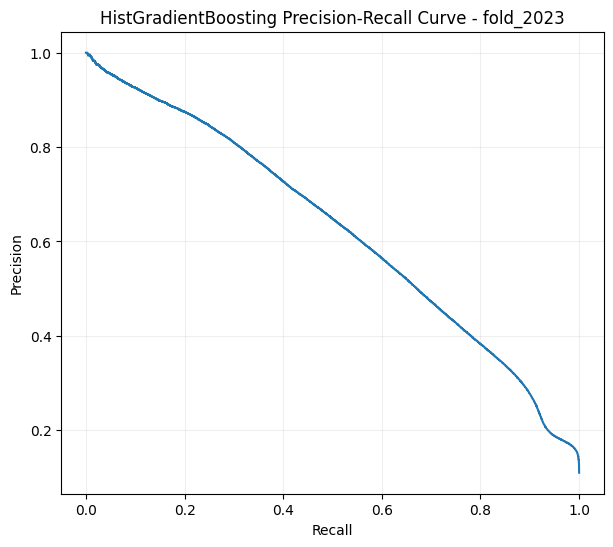

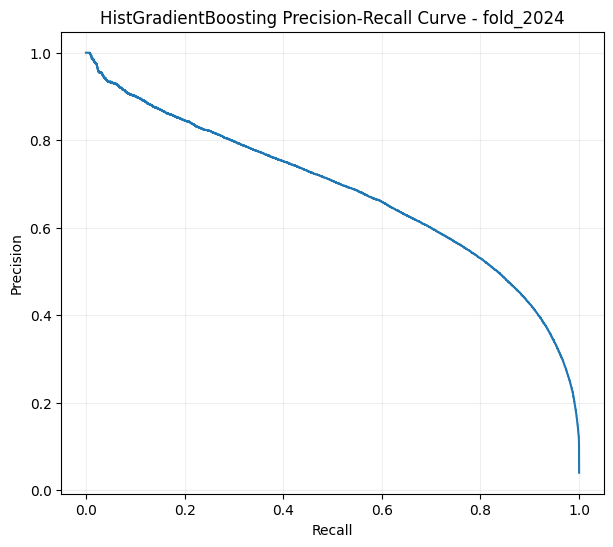

In [15]:
# Precision-Recall curve by validation fold
for fold, group in results["predictions"].groupby("fold"):
    precision, recall, _ = precision_recall_curve(
        group["actual"],
        group["probability"],
    )

    plt.figure(figsize=(7, 6))
    plt.plot(recall, precision)
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(f"HistGradientBoosting Precision-Recall Curve - {fold}")
    plt.grid(alpha=0.2)
    plt.show()


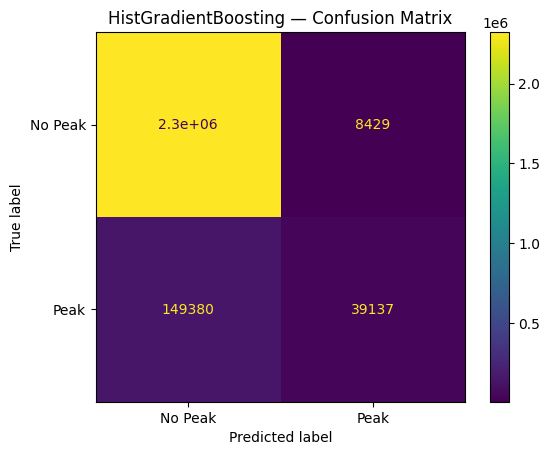

In [16]:
# Global confusion matrix at the shared 0.50 probability threshold
matrix = confusion_matrix(
    results["predictions"]["actual"],
    results["predictions"]["predicted"],
)

display_plot = ConfusionMatrixDisplay(
    confusion_matrix=matrix,
    display_labels=["No Peak", "Peak"],
)

display_plot.plot()
plt.title("HistGradientBoosting — Confusion Matrix")
plt.show()

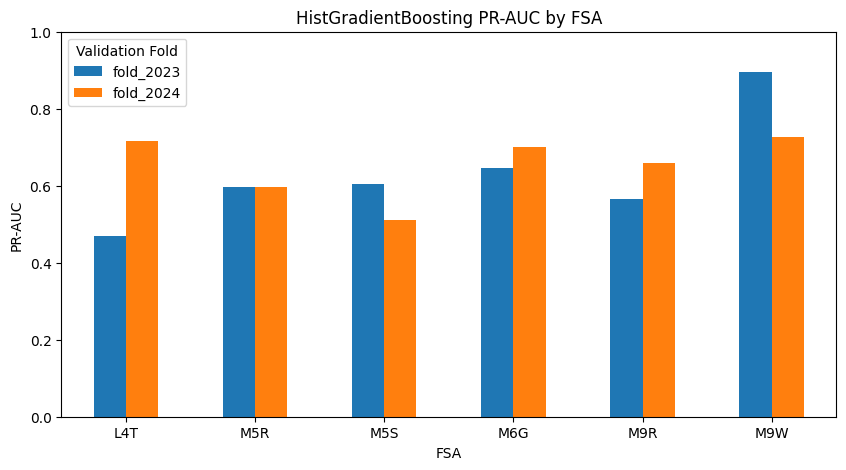

In [17]:
# PR-AUC by FSA and fold
pivot = results["fsa_metrics"].pivot(
    index="fsa",
    columns="fold",
    values="pr_auc",
)

pivot.plot(kind="bar", figsize=(10, 5))
plt.xlabel("FSA")
plt.ylabel("PR-AUC")
plt.title("HistGradientBoosting PR-AUC by FSA")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(title="Validation Fold")
plt.show()

### Interpretation

Review permutation-based predictor importance using representative horizons.

In [18]:
importance = results["permutation_importance"].head(15)
importance

,feature,importance
0,target_lag_24h,0.295079
1,origin__Temp (°C),0.221115
2,target_month_cos,0.128260
3,target_hour,0.127717
4,origin_rolling_mean_24h,0.097124
5,target_hour_sin,0.077345
6,origin__reported_premise_count,0.063689
7,fsa,0.052666
8,origin_rolling_std_24h,0.043453
9,target_month_sin,0.038682


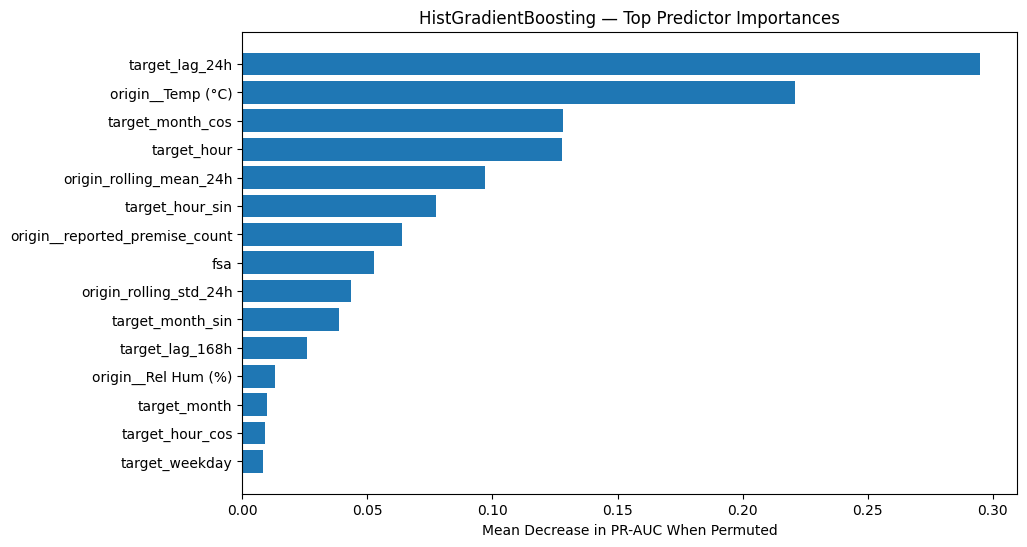

In [19]:
# Plot importance feature
plt.figure(figsize=(10, 6))
plot_data = importance.sort_values("importance")
plt.barh(plot_data["feature"], plot_data["importance"])
plt.xlabel("Mean Decrease in PR-AUC When Permuted")
plt.title("HistGradientBoosting — Top Predictor Importances")
plt.show()

### PR-AUC by horizon

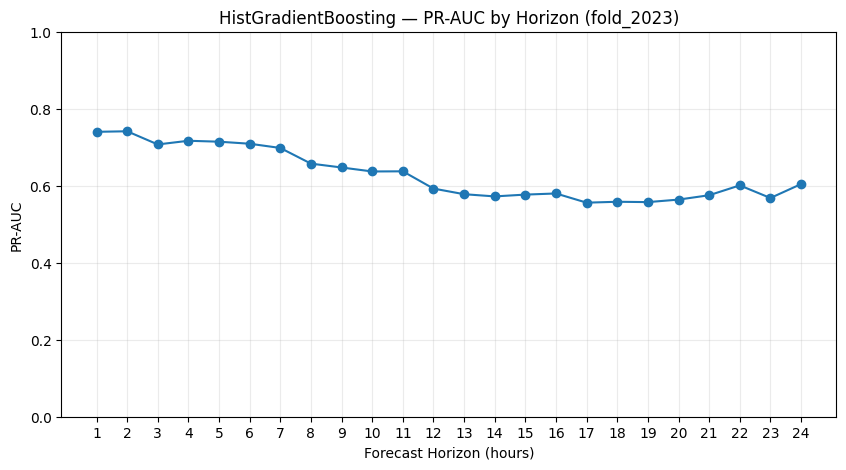

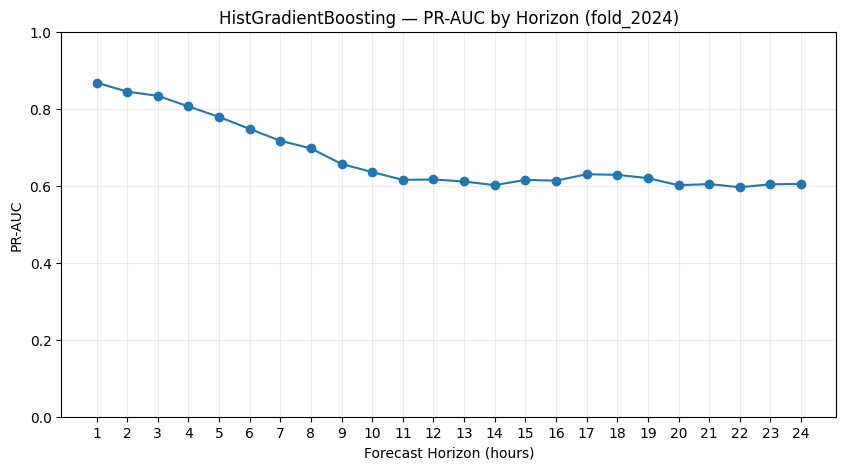

In [20]:
# PR-AUC by prediction horizon.

for fold, group in results[
    "horizon_metrics"
].groupby(
    "fold"
):

    plt.figure(
        figsize=(10, 5)
    )

    plt.plot(
        group["horizon"],
        group["pr_auc"],
        marker="o",
    )

    plt.xlabel(
        "Forecast Horizon (hours)"
    )

    plt.ylabel(
        "PR-AUC"
    )

    plt.title(
        f"HistGradientBoosting — "
        f"PR-AUC by Horizon ({fold})"
    )

    plt.ylim(
        0,
        1,
    )

    plt.xticks(
        range(1, 25)
    )

    plt.grid(
        alpha=0.25
    )

    plt.show()